# FUSION Overview

**Functional Unit State Identification**

**Goal**: Enable interactive integration of 10x Visium and high-resolution kidney histology to link molecular signals with tissue morphology at the lesion level.

**Features**:

- Integrated spatial multi-omics and histology exploration on a web-based interface.
- Functional Tissue Unit–level analysis by linking molecular data with histology.
- Visualizes outputs from computational and AI-based analyses directly in tissue context.
- Enables comparison of molecular signals with tissue morphology to study cellular states.

 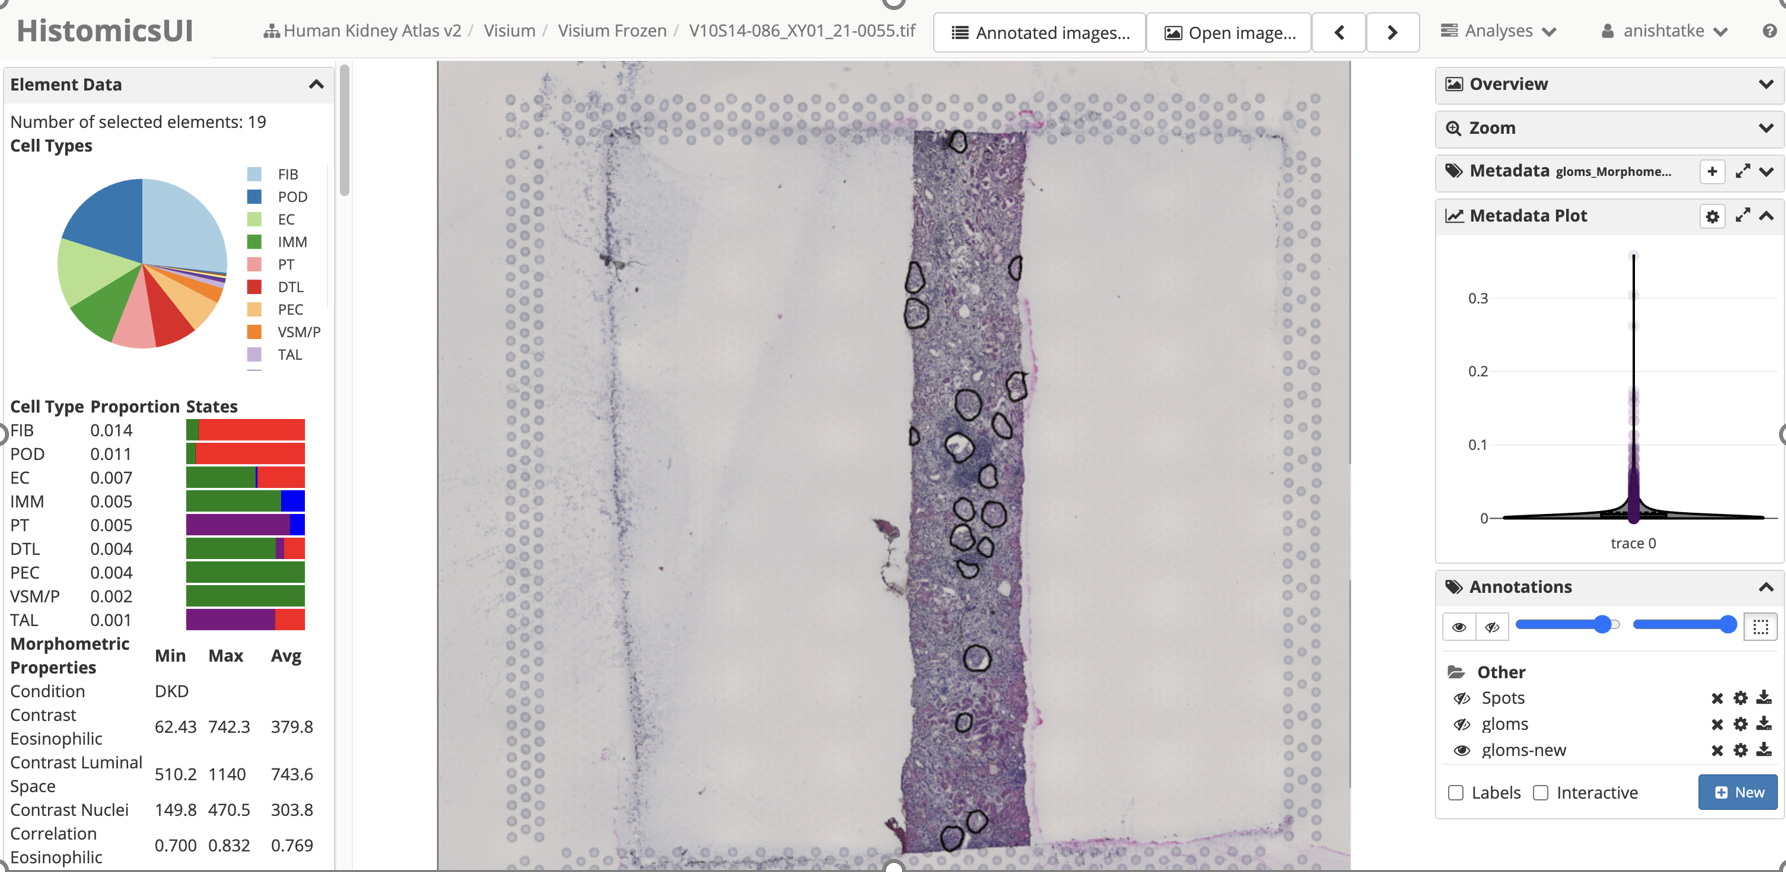

##  Fusion Workflow

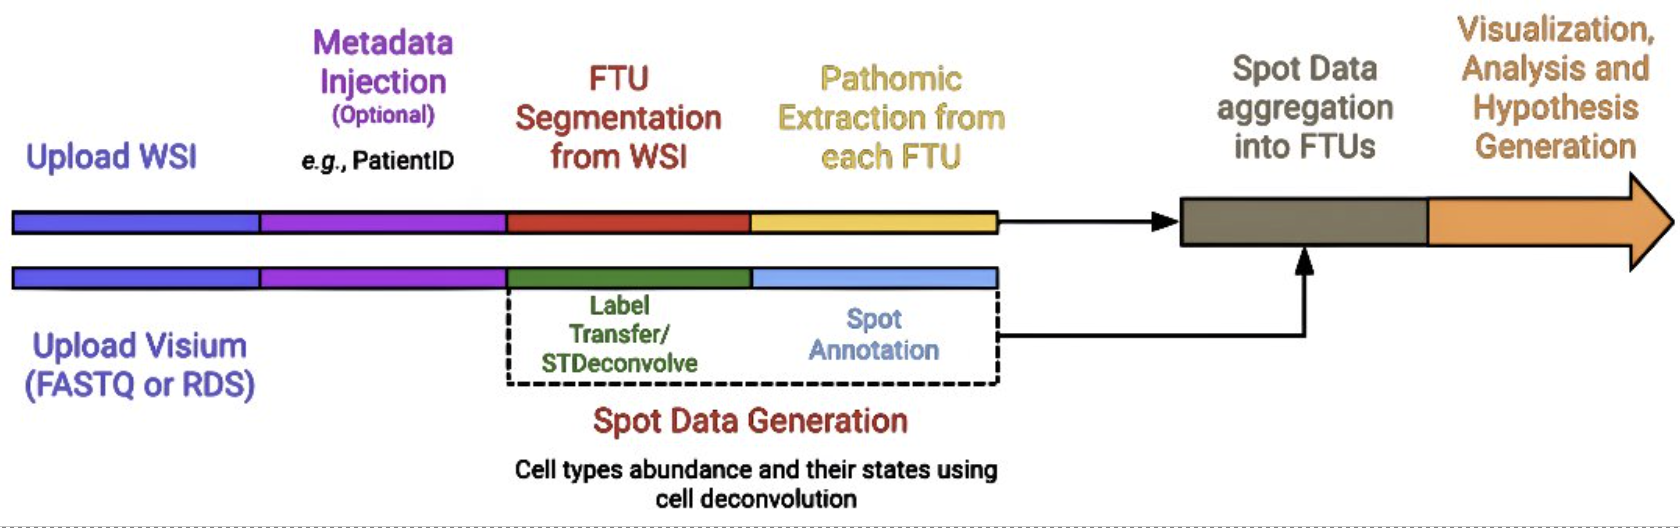

# Initial setup and authentication

In [ ]:
!pip install large_image[all] --find-links https://girder.github.io/large_image_wheels
!jupyter server extension enable jupyter_server_proxy

In [5]:
# Authenticate
user_name='sri15'               # add your user name here 
auth_pass='15110416Sri'         # add your passward here

In [ ]:
import girder_client
gc = girder_client.GirderClient(apiUrl='https://athena.rc.ufl.edu/api/v1')
gc.authenticate(user_name, auth_pass)

# Vizualise HuBMAP data

*Download and vizualise hubmap data using hubmapid in the workspace.*

In [ ]:
Hubmap_id = "HBM442.TWQG.458"

In [ ]:
from fusion.utilities.visualize import visualize_hubmap_wsi
result = visualize_hubmap_wsi(Hubmap_id)
result

# Analysis tasks

**Run analysis jobs**

The following analysis tasks are supported:
- Multi-compartment segmentation
- Glomerulus segmentation
- Feature extraction 
- spatial aggregation
- Cell deconvolution

## Tasks

### Multi-compartment segmentation

**Segments WSIs into 6 compartments:**

- Cortical interstitium
- Medullary interstitium
- Non-sclerotic glomerulus
- Sclerotic glomerulus
- Tubule

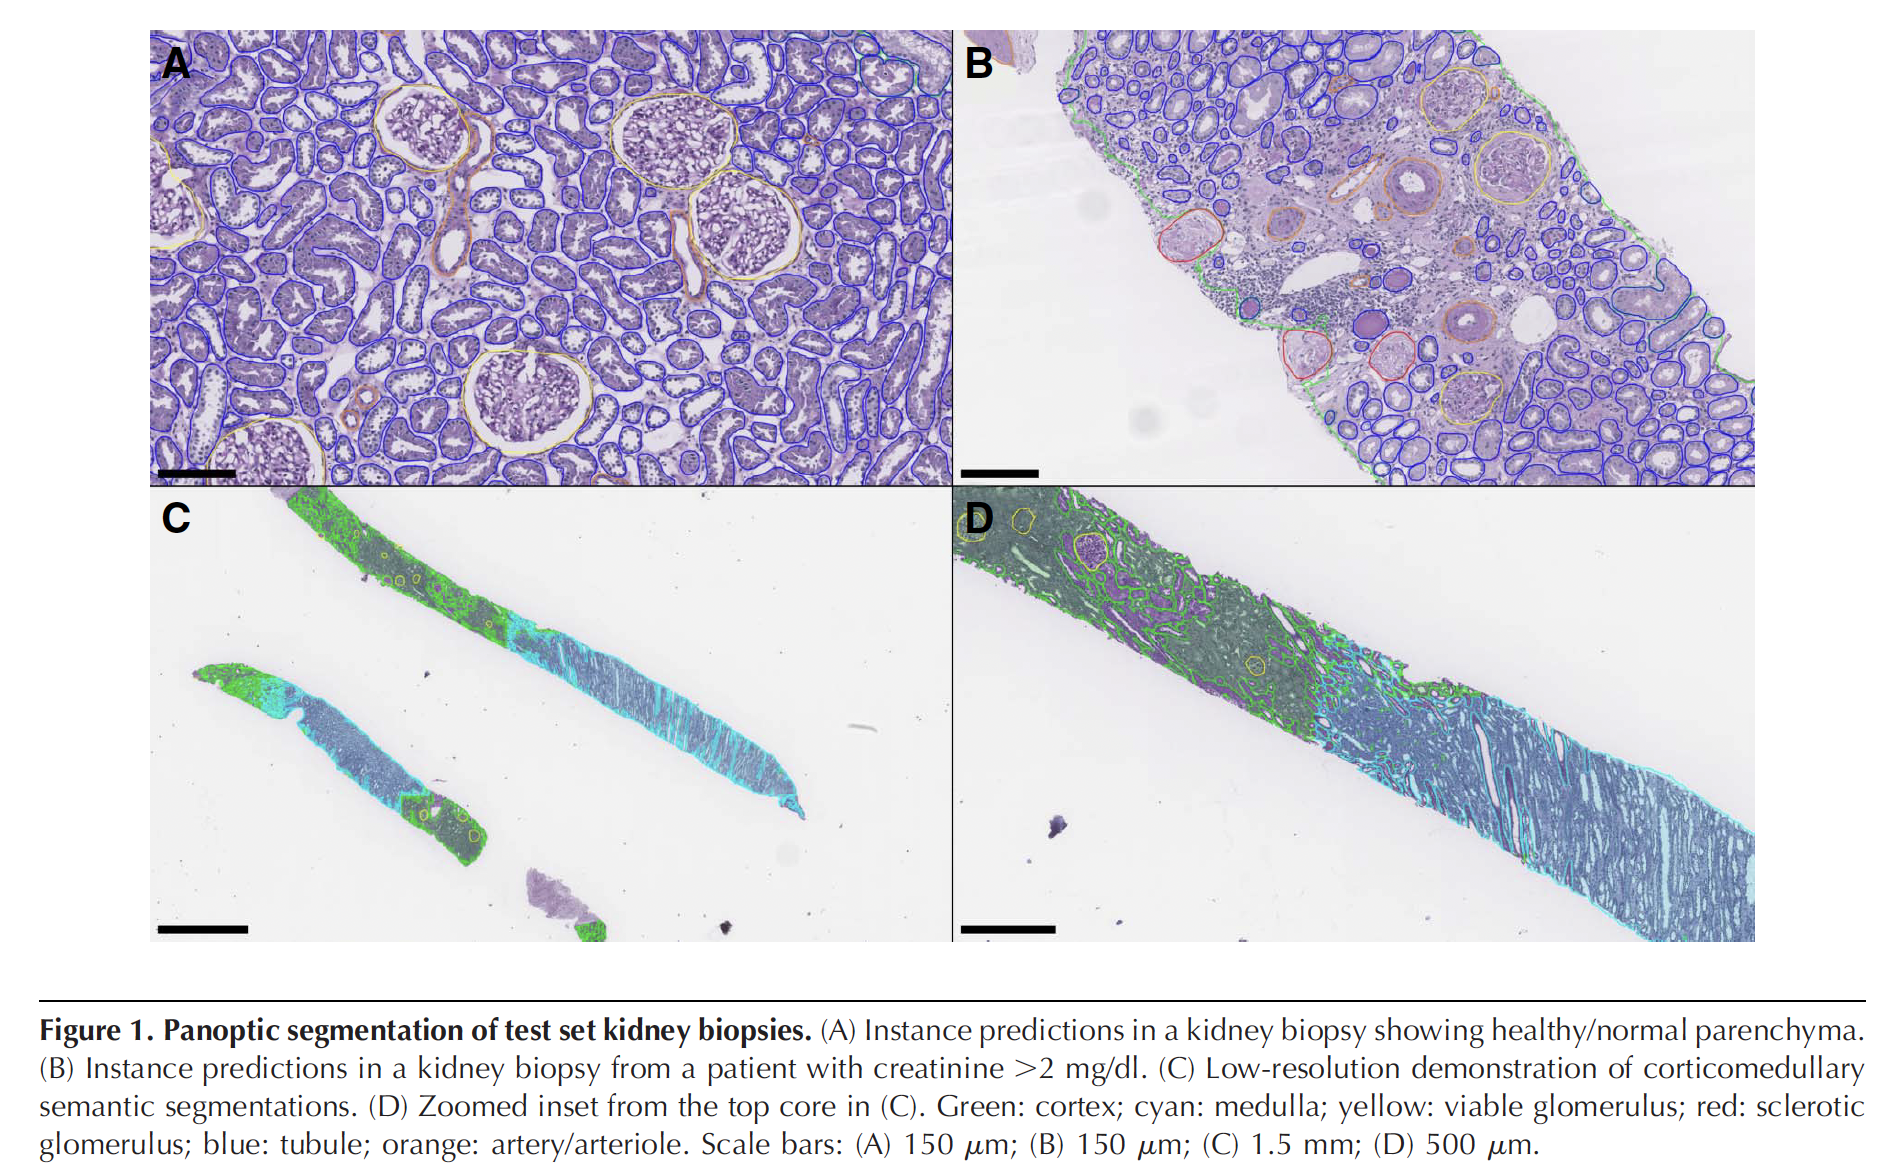

**Expected input** : WSI image and segmentation model file

**Output** : get_multi_compartment_segmentation returns a dictionary object with the following fields:

- `job_id`: unique identifier for the submitted job  
- `plugin_name`: name of the plugin used  
- `raw`: full raw response returned by the backend  
- `file_id`: associated file identifier  
- `folder_id`: associated folder identifier  
- `item_id`: associated item identifier

**Generated files** : 6 annotations JSON files (one for each segmentation)


In [ ]:
from fusion import get_multi_compartment_segmentation

hubmap_id = 'HBM442.TWQG.458' #change this to whatever dataset id you want to use from hubmap.

res = get_multi_compartment_segmentation(gc,user_name,hubmapid=hubmap_id,file_path=None) # You can provide file path instead of hubmapid if the file is in the workspace.

In [ ]:
from fusion import get_job_status

get_job_status(gc, res['job_id'])

In [ ]:
from fusion import poll_job_status

poll_job_status(gc, res['job_id'])

### Glomerulus segmentation

### Feature extraction

### spatial aggregation

### Cell deconvolution

## Vizualise job resuts in FUSION interface

*Vizualise you job's output in a FUSION's interactive interface*

In [ ]:
from fusion import vizualise_in_histomicUI

ts = vizualise_in_histomicUI(res['item_id'])
ts

# Vizualise 10x visium spatial-omics data 

In [ ]:
from fusion import vizualise_in_histomicUI

item_id = "68f7ab7c8248b2deafda85c2"
ts = vizualise_in_histomicUI(item_id)
ts